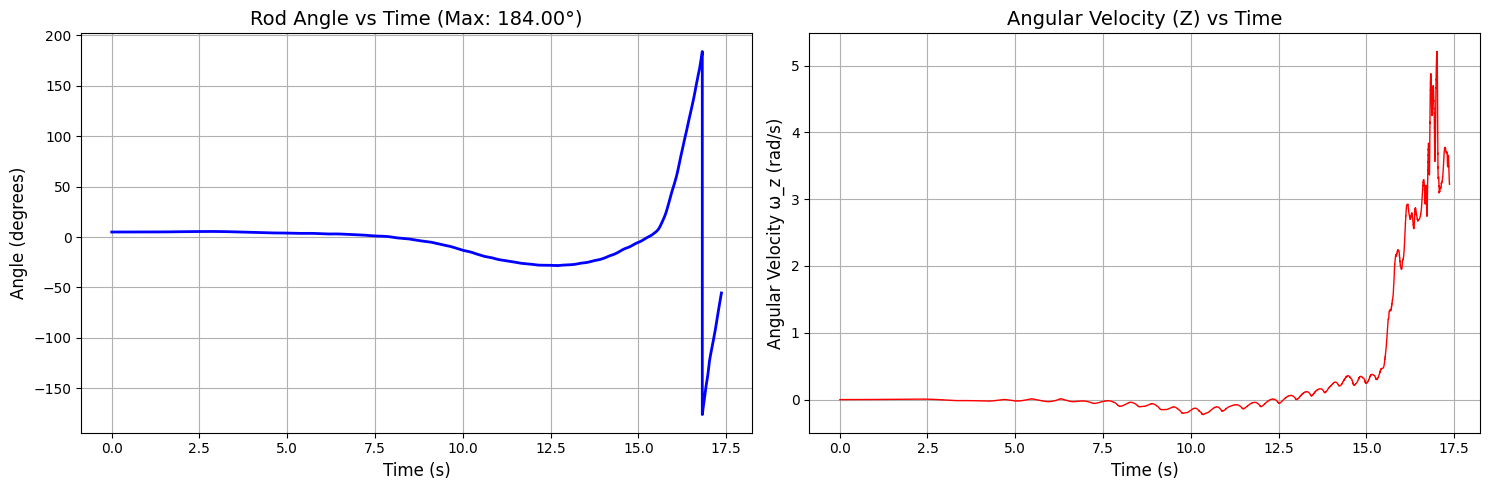

In [6]:
import sys
import re
import math
import matplotlib.pyplot as plt
import math

def plot_angle(log_file):
	times_angle = []
	angles = []
	times_omega = []
	omegas = []
	
	current_time = None
	
	try:
		with open(log_file, 'r') as f:
			for line in f:
				line = line.strip()
				
				# Match time
				m = re.match(r'^Time = ([\d\.eE\+\-]+)', line)
				if m:
					current_time = float(m.group(1))
					continue
					
				# Match orientation
				m = re.match(r'^Orientation:\s*\((.*?)\)', line)
				if m and current_time is not None:
					parts = m.group(1).split()
					if len(parts) == 9:
						xx = float(parts[0])
						yx = float(parts[3])
						
						angle_rad = math.atan2(yx, xx)
						angle_deg = math.degrees(angle_rad)
						angle_deg += 4.0
						
						times_angle.append(current_time)
						angles.append(angle_deg)
						
						current_time = None

				# Match angular velocity (only grab z component)
				m = re.match(r'^Angular velocity:\s*\((.*?)\)', line)
				if m:
					parts = m.group(1).split()
					if len(parts) == 3:
						omega_z = float(parts[2])
						times_omega.append(times_angle[-1] if times_angle else 0)
						omegas.append(omega_z)

		if not times_angle:
			print(f"No orientation data found in '{log_file}'.")
			return

		fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

		# Angle plot
		ax1.plot(times_angle, angles, 'b-', linewidth=2)
		ax1.set_xlabel('Time (s)', fontsize=12)
		ax1.set_ylabel('Angle (degrees)', fontsize=12)
		ax1.set_title(f'Rod Angle vs Time (Max: {max(angles):.2f}°)', fontsize=14)
		ax1.grid(True)

		# Angular velocity plot
		ax2.plot(times_omega, omegas, 'r-', linewidth=1)
		ax2.set_xlabel('Time (s)', fontsize=12)
		ax2.set_ylabel('Angular Velocity ω_z (rad/s)', fontsize=12)
		ax2.set_title('Angular Velocity (Z) vs Time', fontsize=14)
		ax2.grid(True)

		plt.tight_layout()
		plt.show()

	except FileNotFoundError:
		print(f"Error: Log file '{log_file}' not found.")

if __name__ == '__main__':
	log_path = '/home/lavender/OpenFoamUbu/freeFallingFoam/tutorials/RFGTumble2D/combiRun/log.freeFalling6DoFPimpleFoam'
	plot_angle(log_path)


